# Aula 19 — Regressão linear com scikit-learn
Semana 10 | 50 min | Referências: VanderPlas, cap. 5 (Machine Learning) · Jansen, cap. 7 (Linear Models)

## 🎯 Objetivos de aprendizagem
Ao final desta aula, você será capaz de:

- Usar a API de estimadores do scikit-learn: instanciar, `fit`, `predict`, `score`;
- Ajustar uma regressão linear a uma demanda sintetizada e recuperar coeficientes conhecidos;
- Explicar, em uma frase, por que a demanda sobre dados reais de equilíbrio sofre viés de simultaneidade;
- Prever o preço da soja em **R$/sc60kg** com dados REAIS (CBOT + câmbio BCB), com treino/teste sem vazamento;
- Avaliar e interpretar o modelo com R², RMSE e MAE — e ler os coeficientes em unidades econômicas.

## 1. A API de estimadores: três verbos para governar todos os modelos
A economia aplicada vive de perguntas do tipo *"se X sobe 1, quanto muda Y?"*. A regressão linear responde isso com números — e o scikit-learn padroniza **todo** modelo (linear ou não) em três verbos:

1. `modelo = LinearRegression()` — escolhe o método;
2. `modelo.fit(X, y)` — aprende os coeficientes nos dados;
3. `modelo.predict(X_novo)` — gera previsões; `modelo.score(X, y)` devolve o R².

Convenções: `X` é matriz 2D (features), `y` é vetor 1D (alvo); atributos aprendidos terminam em `_` (`coef_`, `intercept_`). Quem aprende um estimador, aprende todos.

In [1]:
# Setup — imports e padrões visuais usados na aula
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def brl(x):
    """Formata um número como moeda brasileira: R$ 1.234,56."""
    return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

DATA = Path("../data/csv")  # o notebook mora em semana_10/
np.random.seed(42)  # reprodutibilidade quando houver aleatoriedade


In [2]:
# O exemplo mínimo: 1 feature, 4 pontos — a reta que passa no meio da nuvem
salario = np.array([1200, 1500, 2200, 3000])          # variável explicativa (R$)
gasto   = np.array([1100, 1300, 1900, 2600])          # alvo (R$)

modelo_min = LinearRegression()            # 1) instancia
modelo_min.fit(salario.reshape(-1, 1), gasto)  # 2) ajusta — X precisa ser 2D

print('coeficiente (inclinação):', modelo_min.coef_)
print('intercepto:', modelo_min.intercept_)
print('R² no próprio treino:', f'{modelo_min.score(salario.reshape(-1, 1), gasto):.3f}')

# Previsão: e se o salário for R$ 2.000?
pred = modelo_min.predict([[2000]])[0]
print('gasto previsto para salário de R$ 2.000:', brl(pred))

coeficiente (inclinação): [0.84176394]
intercepto: 62.51621271076556
R² no próprio treino: 0.999
gasto previsto para salário de R$ 2.000: R$ 1.746,04


## 2. Caso 1 — Demanda sintetizada: o método sabe recuperar a verdade?
Vamos gerar dados de demanda com uma regra conhecida e ver se a regressão recupera os parâmetros. Regra geradora:

$$Q = 500 - 2{,}5 \cdot P + 0{,}8 \cdot Renda + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, 60)$$

Tradução econômica: lei da demanda (preço derruba quantidade, $-2{,}5$), renda empurra consumo ($+0{,}8$ — bem normal), e $arepsilon$ é tudo que o modelo não vê (gosto, clima, promoções). Usamos `np.random.default_rng(42)` — o gerador moderno e reprodutível do NumPy.

In [3]:
# Gerando o mercado artificial com regra conhecida (semente fixa = reprodutível)
rng = np.random.default_rng(42)
n = 200

P = rng.uniform(10, 90, n)          # preço, R$ 10 a 90
renda = rng.normal(3500, 900, n)    # renda mensal do consumidor, R$
q = 500 - 2.5 * P + 0.8 * renda + rng.normal(0, 60, n)  # ruído σ = 60

X_dem = np.column_stack([P, renda])   # matriz de features (n × 2)
y_dem = q                             # alvo: quantidade

print('Primeiras 3 observações (P, renda, Q):')
print(np.round(np.column_stack([P, renda, q])[:3], 2))

Primeiras 3 observações (P, renda, Q):
[[  71.92 4078.99 3629.01]
 [  45.11 3144.86 2916.86]
 [  78.69 3495.39 3131.4 ]]


In [4]:
# A regressão consegue 'adivinhar' a regra que gerou os dados?
modelo_dem = LinearRegression().fit(X_dem, y_dem)

print(f"intercepto: {modelo_dem.intercept_:.1f}   (verdade ≈ 500)")
print(f"coef. preço: {modelo_dem.coef_[0]:.3f}   (verdade = -2,5)")
print(f"coef. renda: {modelo_dem.coef_[1]:.3f}   (verdade = +0,8)")
print(f"R²: {modelo_dem.score(X_dem, y_dem):.3f}")

intercepto: 485.6   (verdade ≈ 500)
coef. preço: -2.388   (verdade = -2,5)
coef. renda: 0.802   (verdade = +0,8)
R²: 0.993


**Leitura do resultado.** Os coeficientes chegam perto da verdade (≈ $-2{,}4$ e $+0{,}8$) mas não cravam: o **ruído** ($\varepsilon$) e o tamanho da amostra explicam o desvio. Isso é o ensaio de fumaça — sabemos a resposta, então qualquer erro é do código, não do mundo.

**A ressalva honesta — simultaneidade.** Com dados **reais** de mercado, preço e quantidade são observados *no equilíbrio*: secas deslocam a oferta, e o preço sobe enquanto a quantidade cai — a regressão sobre dados de equilíbrio mistura os dois deslocamentos e o coeficiente de preço fica **enviesado** (o problema clássico de identificação da curva de demanda). Por isso geramos a demanda sintetizada com preço e renda definidos *antes* do ruído. Nos dados reais a seguir, mudamos a pergunta: em vez de *identificar demanda*, **prevemos o preço em reais** — problema preditivo legítimo, em que a nota é o R² fora da amostra.

## 3. Caso 2 (dados REAIS) — Soja: de US$/bushel a R$/saca
O produtor de Rio Verde (GO) vende em reais, mas o preço-âncora é o futuro da CBOT em dólares. A identidade de conversão:

$$\text{preço}_{R\$/sc} = \underbrace{\text{preço}_{US\$/bu} \times \frac{60}{27{,}216}}_{\text{US\$/sc}} \times \; \text{câmbio}_{R\$/US\$}$$

1 bushel = 27,216 kg; 1 saca = 60 kg. O CSV da CBOT vem em **centavos** de dólar (`close` ≈ 1294 = US$ 12,94/bu) — dividir por 100 antes de tudo, ou o preço da saca sai 100× maior. Fontes: `soja_cbot_usd_bushel.csv` (yfinance ZS=F) e `usdbrl_diario.csv` (BCB-SGS 1, `sep=';'`, `decimal=','`, datas dd/mm/aaaa).

In [5]:
# Coleta + tratamento: duas fontes, formatos diferentes, um merge por data
# BCB: separador ';', decimal ',', data dd/mm/aaaa  |  CBOT: data ISO aaaa-mm-dd
soja = pd.read_csv(DATA / 'soja_cbot_usd_bushel.csv')
soja['data'] = pd.to_datetime(soja['date'], format='%Y-%m-%d')
soja = soja.rename(columns={'close': 'usd_bu'})[['data', 'usd_bu']]

cambio = pd.read_csv(DATA / 'usdbrl_diario.csv', sep=';', decimal=',')
cambio['data'] = pd.to_datetime(cambio['data'], format='%d/%m/%Y', dayfirst=True)
cambio = cambio.rename(columns={'valor': 'cambio'})[['data', 'cambio']]

df = soja.merge(cambio, on='data', how='inner')   # só dias com cotação nas DUAS fontes
df['usd_sc'] = df['usd_bu'] / 100 * 60 / 27.216   # centavos/bu → US$/sc60kg
df['rs_sc'] = df['usd_sc'] * df['cambio']         # → R$/sc60kg
df = df.dropna().reset_index(drop=True)

print(df.shape)
df.tail(3)

(2366, 5)


,data,usd_bu,cambio,usd_sc,rs_sc
2363,2026-09-02,1301.75,5.1273,28.698192,147.144241
2364,2026-09-03,1306.25,5.0962,28.797399,146.757303
2365,2026-09-04,1293.75,5.1253,28.521825,146.182912


In [6]:
# Checagem de sanidade das unidades (o erro de 100× mora aqui)
ultimo = df.iloc[-1]
print(f"CBOT: {ultimo['usd_bu']:.0f} US cents/bu = US$ {ultimo['usd_bu']/100:.2f}/bu")
print(f"Câmbio: R$ {ultimo['cambio']:.4f}/US$")
print(f"Soja em US$/sc: {ultimo['usd_sc']:.2f}")
print(f"Soja em R$/sc:  {brl(ultimo['rs_sc'])}")

CBOT: 1294 US cents/bu = US$ 12.94/bu
Câmbio: R$ 5.1253/US$
Soja em US$/sc: 28.52
Soja em R$/sc:  R$ 146,18


## 4. Feature engineering — o retorno de 21 dias
Além do nível (câmbio, preço internacional), traders olham **momentum**: o preço vem subindo ou caindo no último mês de pregões? O retorno de 21 pregões (`pct_change(21)`) captura isso. A primeira linha perde a janela e vira `NaN` — por isso o `dropna()` na hora de modelar.

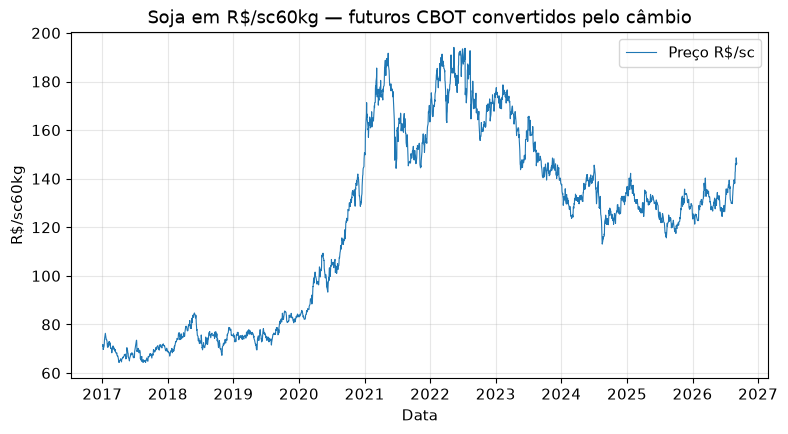

In [7]:
# Momentum: retorno acumulado em 21 pregões (~1 mês de mercado)
df['ret21'] = df['rs_sc'].pct_change(21)

fig, ax = plt.subplots()
ax.plot(df['data'], df['rs_sc'], lw=0.8, label='Preço R$/sc')
ax.set_title('Soja em R$/sc60kg — futuros CBOT convertidos pelo câmbio')
ax.set_xlabel('Data'); ax.set_ylabel('R$/sc60kg')
ax.legend()
plt.show()

## 5. Treino/teste sem trapacear: `shuffle=False`
Nosso alvo é o preço em R$/sc; features: **câmbio**, **preço em US$/sc** e **retorno 21d**. Vamos treinar com os primeiros 75% das datas e testar nos 25% mais recentes — o modelo nunca pode ter visto o futuro. Em série temporal isso exige `shuffle=False` (o padrão do `train_test_split` é embaralhar, o que vaza o futuro para o treino — Jansen, cap. 8, chama isso de *data leakage*).

In [8]:
# Divisão temporal: treino = passado, teste = o ano mais recente
features = ['cambio', 'usd_sc', 'ret21']
dado = df.dropna(subset=features + ['rs_sc'])

X = dado[features].to_numpy()
y = dado['rs_sc'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, shuffle=False)  # shuffle=False = sem vazamento

print(f'treino: {len(y_train)} dias  |  teste: {len(y_test)} dias')
print('datas do teste:', dado['data'].iloc[-len(y_test):].min().date(), '→',
      dado['data'].iloc[-len(y_test):].max().date())

treino: 1758 dias  |  teste: 587 dias
datas do teste: 2024-04-17 → 2026-09-04


In [9]:
# Ajustar no treino, medir no teste — cada verbo no seu lugar
modelo = LinearRegression().fit(X_train, y_train)
y_pred = modelo.predict(X_test)

r2_treino = modelo.score(X_train, y_train)
r2_teste  = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print(f'R² treino: {r2_treino:.3f}   R² teste: {r2_teste:.3f}')
print(f'RMSE: {rmse:.2f} R$/sc   MAE: {mae:.2f} R$/sc')

R² treino: 0.998   R² teste: 0.950
RMSE: 1.40 R$/sc   MAE: 1.29 R$/sc


## 6. Interpretando coeficientes (em reais, não em abstrato)
Com o modelo ajustado, cada coeficiente responde *"segurando as outras features constantes, quanto muda o preço da saca se esta feature subir 1 unidade?"*

In [10]:
# Coeficientes em unidades econômicas
print(f'intercepto: {modelo.intercept_:.1f}')
for nome, b in zip(features, modelo.coef_):
    print(f'{nome:8s}: {b:+.2f} R$/sc por unidade da feature')

intercepto: -109.0
cambio  : +22.31 R$/sc por unidade da feature
usd_sc  : +4.96 R$/sc por unidade da feature
ret21   : +0.71 R$/sc por unidade da feature


**Leitura.** O coeficiente do câmbio (≈ **+22 R$/sc por +1 R$/US$**) responde a pergunta do produtor goiano: se o dólar sobe um real, com o preço internacional constante, a saca sobe ~22 reais. O coeficiente do preço em US$ (≈ **+4,9**) aproxima-se do câmbio médio da amostra (~5,1) — reflexo da identidade de conversão. O `ret21` pega o momentum residual. Lembre: coeficiente resume **associação**; causalidade exige desenho de identificação.

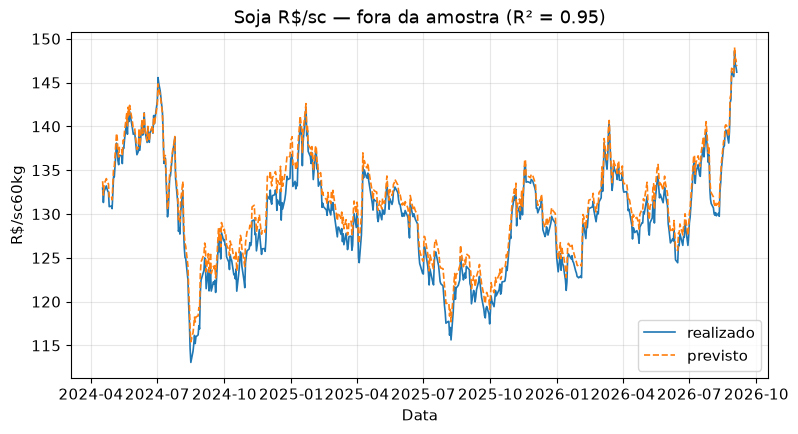

In [11]:
# Visual: realizado vs previsto no teste — onde o modelo acerta e onde erra?
datas_teste = dado['data'].iloc[-len(y_test):].to_numpy()

fig, ax = plt.subplots()
ax.plot(datas_teste, y_test, lw=1.2, label='realizado')
ax.plot(datas_teste, y_pred, lw=1.2, ls='--', label='previsto')
ax.set_title(f'Soja R$/sc — fora da amostra (R² = {r2_teste:.2f})')
ax.set_xlabel('Data'); ax.set_ylabel('R$/sc60kg')
ax.legend()
plt.show()

In [12]:
# Baseline tolo: 'prever o último preço do treino' — nosso modelo precisa vencer isso
baseline_pred = np.full_like(y_test, y_train[-1])   # persistência
rmse_base = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f'RMSE modelo:    {rmse:.2f} R$/sc')
print(f'RMSE baseline:  {rmse_base:.2f} R$/sc')
print('Venceu o baseline?' , 'SIM' if rmse < rmse_base else 'NÃO')

RMSE modelo:    1.40 R$/sc
RMSE baseline:  7.06 R$/sc
Venceu o baseline? SIM


## 📝 Exercícios
Faça antes de olhar as soluções. Todos usam o `df` e os modelos já criados.

1. **Outro ruído.** Gere a demanda com `rng.normal(0, 150, n)` (ruído 2,5× maior), ajuste a regressão e compare os coeficientes com o Caso 1. O que mais ruído faz com as estimativas?
2. **Só o câmbio.** Ajuste um modelo **univariado** (apenas `cambio`) para prever `rs_sc`, com o mesmo split. Qual o R² de teste? Compare com o modelo completo.
3. **Baseline tolo**. Some o `ret21` à lista de features... na verdade, teste o contrário: remova `ret21` (features = `['cambio', 'usd_sc']`) e refaça o split + ajuste + métricas. O momentum ajudava mesmo?
4. **Cenário de câmbio.** Com o modelo completo, fixe `usd_sc = 12.9` e `ret21 = 0.0` e preveja o preço da saca para câmbio de 5,00 / 5,50 / 6,00 R$/US$. Interprete a diferença entre cenários com `brl()`.

In [13]:
# EXERCÍCIO 1 — seu código aqui

In [14]:
# SOLUÇÃO 1 — ruído maior ⇒ estimativas mais longe da verdade (mesmo n)
q2 = 500 - 2.5 * P + 0.8 * renda + rng.normal(0, 150, n)
m2 = LinearRegression().fit(X_dem, q2)
print(f"ruído σ=150 → coef. preço: {m2.coef_[0]:.3f} | renda: {m2.coef_[1]:.3f}")
print('comparado ao σ=60 da aula (≈ -2,39 e +0,80), os valores se afastam mais: mais ruído = menos precisão.')

ruído σ=150 → coef. preço: -2.055 | renda: 0.790
comparado ao σ=60 da aula (≈ -2,39 e +0,80), os valores se afastam mais: mais ruído = menos precisão.


In [15]:
# EXERCÍCIO 2 — seu código aqui

In [16]:
# SOLUÇÃO 2 — só o câmbio: R² cai para ≈ 0,6 (o preço em US$ é a maior fonte de variação)
X_uni = dado[['cambio']].to_numpy()          # colchetes duplos = DataFrame 2D
Xtr_u, Xte_u, ytr_u, yte_u = train_test_split(
    X_uni, y, test_size=0.25, random_state=42, shuffle=False)
m_uni = LinearRegression().fit(Xtr_u, ytr_u)
pred_u = m_uni.predict(Xte_u)
print(f'R² teste univariado: {r2_score(yte_u, pred_u):.3f}  (completo: {r2_teste:.3f})')
print(f'coef. câmbio univariado: {m_uni.coef_[0]:+.2f} R$/sc por +1 R$/US$')

R² teste univariado: -26.525  (completo: 0.950)
coef. câmbio univariado: +43.68 R$/sc por +1 R$/US$


In [17]:
# EXERCÍCIO 3 — seu código aqui

In [18]:
# SOLUÇÃO 3 — sem momentum: métrica quase não muda (o nível domina o retorno)
X_sem = dado[['cambio', 'usd_sc']].to_numpy()
Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(
    X_sem, y, test_size=0.25, random_state=42, shuffle=False)
m_sem = LinearRegression().fit(Xtr_s, ytr_s)
pred_s = m_sem.predict(Xte_s)
print(f'R² teste sem ret21: {r2_score(yte_s, pred_s):.4f} | com ret21: {r2_teste:.4f}')
print('o ret21 adiciona pouco: a identidade de conversão já explica quase tudo.')

R² teste sem ret21: 0.9479 | com ret21: 0.9496
o ret21 adiciona pouco: a identidade de conversão já explica quase tudo.


In [19]:
# EXERCÍCIO 4 — seu código aqui

In [20]:
# SOLUÇÃO 4 — tabela de cenários: a leitura ceteris paribus do coeficiente
cenarios = pd.DataFrame({'cambio': [5.00, 5.50, 6.00],
                         'usd_sc': 12.9, 'ret21': 0.0})
cenarios['preco_previsto'] = modelo.predict(cenarios[features])
cenarios['preco_brl'] = cenarios['preco_previsto'].map(brl)
cenarios.set_index('cambio')[['preco_brl']]

/Users/yurifloresalbuquerque/Documents/cursos_2s_2026/OIKOS/curso_de_python/.venv_oikos/lib/python3.11/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


,preco_brl
cambio,
5.0,"R$ 66,54"
5.5,"R$ 77,70"
6.0,"R$ 88,86"


## 📌 Resumo & para casa
- A API do scikit-learn é um contrato de três verbos: `fit`, `predict`, `score` — vale para regressão e para todo modelo futuro;
- Demanda sintetizada recuperou os coeficientes (≈ −2,4; +0,8): método validado, e o desvio vem do ruído;
- Simultaneidade: demanda sobre dados de equilíbrio real é enviesada — por isso mudamos para o problema preditivo;
- Preço da soja em R$/sc previsto com R² de teste ≈ 0,95 e RMSE ≈ 1,5 R$/sc; câmbio ≈ +22 R$/sc por +1 R$/US$;
- `shuffle=False` em série temporal: treinar no passado e testar no futuro é o mínimo de honestidade;
- Toda métrica vale pouco sem baseline: sempre compare com o modelo tolo.

**Para casa:** refazer o Caso 2 com o milho (`milho_cbot_usd_bushel.csv`). Na Aula 20, o projeto final empacota esta esteira num mini-relatório de consultoria.

**Referências KB:**
- `kb/02_vanderplas_python_data_science_handbook/08_chapter-5-machine-learning.md`
- `kb/03_jansen_ml_for_algorithmic_trading/13_chapter-7-linear-models-from-risk-factors-to-return-forecast.md`